In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

In [2]:
def show_plt(column, title, x_label, y_label = "Count"):
    plt.hist(
    column, 
    bins=20,             
    edgecolor='black',   
    rwidth=0.85,         
    )
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

Load dataset

In [3]:
dogs_df = pd.read_csv('data/dogs_dataset.csv')

Describe dataset

In [4]:
dogs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Breed        3000 non-null   str  
 1   Age (Years)  3000 non-null   int64
 2   Weight (kg)  3000 non-null   int64
 3   Color        3000 non-null   str  
 4   Gender       3000 non-null   str  
dtypes: int64(2), str(3)
memory usage: 117.3 KB


In [5]:
print(dogs_df.describe())

       Age (Years)  Weight (kg)
count  3000.000000  3000.000000
mean      7.499000    32.059667
std       4.011238    15.628463
min       1.000000     5.000000
25%       4.000000    19.000000
50%       8.000000    33.000000
75%      11.000000    45.000000
max      14.000000    59.000000


In [6]:
print(f"Generalno: mean={dogs_df['Weight (kg)'].mean():.2f}, std={dogs_df['Weight (kg)'].std():.2f}")

Generalno: mean=32.06, std=15.63


In [7]:
grouped_by_breed = dogs_df.groupby('Breed')['Weight (kg)'].agg(['mean', 'std', 'count'])
print(grouped_by_breed.sort_values('mean'))

                                    mean        std  count
Breed                                                     
Siberian Husky                 28.188679  15.890317     53
Chesapeake Bay Retriever       28.192308  15.003318     52
French Bulldog                 28.957143  15.170944     70
Belgian Malinois               29.113636  15.318655     44
Yorkshire Terrier              29.471698  14.228362     53
West Highland White Terrier    29.520833  18.118980     48
Jack Russell Terrier           29.545455  14.828424     55
Weimaraner                     29.863636  14.363293     66
Lhasa Apso                     29.946429  15.750809     56
Vizsla                         29.968750  15.145819     64
Doberman Pinscher              30.075758  16.585731     66
Shetland Sheepdog              30.200000  16.467655     50
Cavalier King Charles Spaniel  30.234375  15.476292     64
Chihuahua                      30.250000  16.023254     48
Border Collie                  30.526316  15.913949     

In [8]:
grouped_by_age = dogs_df.groupby('Age (Years)')['Weight (kg)'].agg(['mean', 'std', 'count'])
print(grouped_by_age.sort_values('mean'))

                  mean        std  count
Age (Years)                             
4            30.228155  15.195358    206
12           30.816964  15.119479    224
9            31.115044  15.204533    226
14           31.133005  16.316700    203
8            31.138756  14.926901    209
2            31.448780  15.843090    205
3            31.543689  15.774185    206
7            32.013453  15.054101    223
11           32.458333  15.369802    216
10           33.115741  16.096816    216
5            33.148837  15.798562    215
1            33.222222  16.494708    225
13           33.605769  15.684953    208
6            33.711009  15.789046    218


In [9]:
grouped_by_gender = dogs_df.groupby('Gender')['Weight (kg)'].agg(['mean', 'std', 'count'])
print(grouped_by_gender.sort_values('mean'))

             mean        std  count
Gender                             
Female  31.903289  15.692502   1520
Male    32.220270  15.566086   1480


Load real weights dataset

In [10]:
real_df = pd.read_csv('data/real_weights.csv')

Describe real weights dataset

In [11]:
real_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         277 non-null    str    
 1   description                  277 non-null    str    
 2   temperament                  276 non-null    str    
 3   popularity                   198 non-null    str    
 4   min_height                   277 non-null    float64
 5   max_height                   277 non-null    float64
 6   min_weight                   275 non-null    float64
 7   max_weight                   275 non-null    float64
 8   min_expectancy               274 non-null    float64
 9   max_expectancy               274 non-null    float64
 10  group                        277 non-null    str    
 11  grooming_frequency_value     270 non-null    float64
 12  grooming_frequency_category  270 non-null    str    
 13  shedding_value               25

In [12]:
print(real_df.describe().filter(items=["min_weight", "max_weight"]))

       min_weight  max_weight
count  275.000000  275.000000
mean    17.888858   27.291416
std     12.290600   19.061416
min      0.000000    0.000000
25%      8.164663   12.927383
50%     15.875733   24.947580
75%     22.679619   34.019428
max     68.038855  108.862169


In [13]:
real_weights = real_df.get(["name", "min_weight", "max_weight"])
print(real_weights.sort_values(["min_weight", "max_weight"]))

                  name  min_weight  max_weight
65          Cane Corso    0.000000    0.000000
194         Pomeranian    1.360777    3.175147
259    Toy Fox Terrier    1.587573    3.175147
197       Poodle (Toy)    1.814369    2.721554
38      Biewer Terrier    1.814369    3.628739
..                 ...         ...         ...
208   Pyrenean Mastiff   54.431084  108.862169
242    Spanish Mastiff   63.502932   90.718474
43            Boerboel   68.038855   90.718474
16   Australian Kelpie         NaN         NaN
244   Spinone Italiano         NaN         NaN

[277 rows x 3 columns]


In [14]:
print(real_weights.sort_values(["max_weight"], ascending=False))

                  name  min_weight  max_weight
208   Pyrenean Mastiff   54.431084  108.862169
164            Mastiff   54.431084  104.326245
242    Spanish Mastiff   63.502932   90.718474
43            Boerboel   68.038855   90.718474
258               Tosa   45.359237   90.718474
..                 ...         ...         ...
74           Chihuahua    2.721554    2.721554
197       Poodle (Toy)    1.814369    2.721554
65          Cane Corso    0.000000    0.000000
16   Australian Kelpie         NaN         NaN
244   Spinone Italiano         NaN         NaN

[277 rows x 3 columns]


In [15]:
anomalies = real_df[real_df["max_weight"] < real_df["min_weight"]]
print(f"Number of anomalies (max < min): {len(anomalies)}")
print(anomalies[["name", "min_weight", "max_weight"]])

Number of anomalies (max < min): 0
Empty DataFrame
Columns: [name, min_weight, max_weight]
Index: []


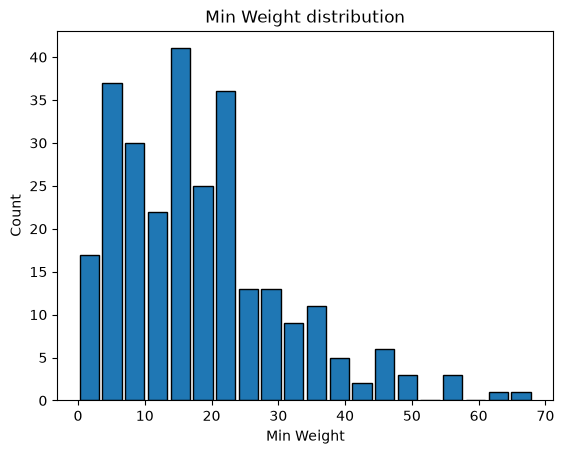

In [16]:
show_plt(real_df['min_weight'], "Min Weight distribution",
         "Min Weight")

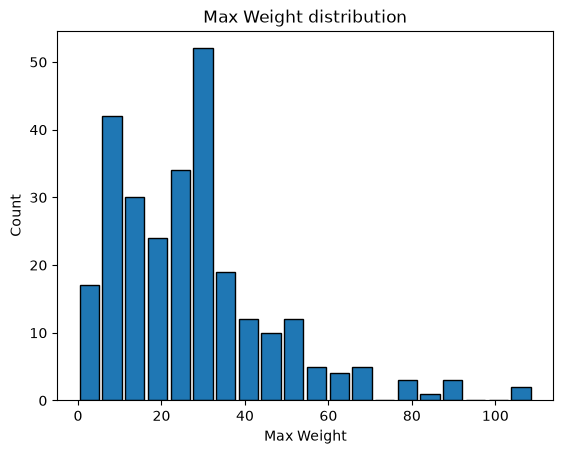

In [17]:
show_plt(real_df['max_weight'], "Max Weight distribution",
         "Max Weight")

Check for race names

In [18]:
names_not_in_other_dataset = dogs_df.loc[~dogs_df["Breed"].isin(real_df["name"]), "Breed"].unique()
print(f"Count of names not in other dataset: {len(names_not_in_other_dataset)}")

Count of names not in other dataset: 4


Merge different types of races of the same race

In [19]:
poodles_weights = real_df[real_df['name'].str.contains('poodle', case=False, na=False)].get(["name", "min_weight", "max_weight"])
print(poodles_weights)
poodle_min_weight = poodles_weights["min_weight"].min()
poodle_max_weight = poodles_weights["max_weight"].max()
print(poodle_min_weight)
print(poodle_max_weight)

                   name  min_weight  max_weight
195  Poodle (Miniature)    4.535924    6.803886
196   Poodle (Standard)   18.143695   31.751466
197        Poodle (Toy)    1.814369    2.721554
1.81436948
31.751465900000003


In [20]:
schnauzer_weights = real_df[real_df['name'].str.contains('schnauzer', case=False, na=False)].get(["name", "min_weight", "max_weight"])
print(schnauzer_weights)
schnauzer_min_weight = schnauzer_weights["min_weight"].min()
schnauzer_max_weight = schnauzer_weights["max_weight"].max()
print(schnauzer_min_weight)
print(schnauzer_max_weight)

                    name  min_weight  max_weight
118      Giant Schnauzer   24.947580   38.555351
168  Miniature Schnauzer    4.989516    9.071847
247   Standard Schnauzer   13.607771   22.679619
4.9895160700000005
38.55535145


In [21]:
new_rows = pd.DataFrame([
    {'name': 'Poodle', 'min_weight': poodle_min_weight, "max_weight": poodle_max_weight},
    {'name': 'Schnauzer', 'min_weight': schnauzer_min_weight, "max_weight": schnauzer_max_weight}
])

real_df = pd.concat([real_df, new_rows], ignore_index=True)

In [22]:
poodle_min = real_df[real_df['name']=='Poodle']['min_weight'].iloc[0]
poodle_max = real_df[real_df['name']=='Poodle']['max_weight'].iloc[0]
poodle_std = (poodle_max - poodle_min) / 4

schnauzer_min = real_df[real_df['name']=='Schnauzer']['min_weight'].iloc[0]
schnauzer_max = real_df[real_df['name']=='Schnauzer']['max_weight'].iloc[0]
schnauzer_std = (schnauzer_max - schnauzer_min) / 4

print(f"Poodle std: {poodle_std:.2f}")
print(f"Schnauzer std: {schnauzer_std:.2f}")

real_df['computed_std'] = (real_df['max_weight'] - real_df['min_weight']) / 4
print(f"Medijana std preko svih rasa: {real_df['computed_std'].median():.2f}")
print(f"Prosjek std preko svih rasa: {real_df['computed_std'].mean():.2f}")

print(f"Poodle std percentil: {(real_df['computed_std'] < poodle_std).mean()*100:.1f}%")
print(f"Schnauzer std percentil: {(real_df['computed_std'] < schnauzer_std).mean()*100:.1f}%")

Poodle std: 7.48
Schnauzer std: 8.39
Medijana std preko svih rasa: 1.70
Prosjek std preko svih rasa: 2.39
Poodle std percentil: 96.1%
Schnauzer std percentil: 97.1%


In [23]:
breed_name_mapping = {
    "Airedale Terrier": "Airedale Terrier",
    "Jack Russell Terrier": "Russell Terrier",
    "Dogo Argentino": "Dogo Argentino",
    "Labrador Retriever": "Labrador Retriever",
    "French Bulldog": "French Bulldog",
    "Bull Terrier": "Bull Terrier",
    "Boxer": "Boxer",
    "Cocker Spaniel": "Cocker Spaniel",
    "Shetland Sheepdog": "Shetland Sheepdog",
    "Whippet": "Whippet",
    "Weimaraner": "Weimaraner",
    "Havanese": "Havanese",
    "Beagle": "Beagle",
    "Maltese": "Maltese",
    "Siberian Husky": "Siberian Husky",
    "German Shepherd": "German Shepherd Dog",
    "Bloodhound": "Bloodhound",
    "Irish Setter": "Irish Setter",
    "Doberman Pinscher": "Doberman Pinscher",
    "Vizsla": "Vizsla",                
    "Bernese Mountain Dog": "Bernese Mountain Dog",
    "Shih Tzu": "Shih Tzu",
    "Yorkshire Terrier": "Yorkshire Terrier",
    "Boston Terrier": "Boston Terrier",
    "Chinese Shar-Pei": "Chinese Shar-Pei",
    "Pug": "Pug",
    "Poodle": "Poodle",
    "Australian Shepherd": "Australian Shepherd",
    "Miniature Schnauzer": "Miniature Schnauzer",
    "Saint Bernard": "Saint Bernard",
    "Rottweiler": "Rottweiler",
    "Pekingese": "Pekingese",
    "Chihuahua": "Chihuahua",
    "Shiba Inu": "Shiba Inu",
    "Schnauzer": "Schnauzer",
    "Dachshund": "Dachshund",
    "Papillon": "Papillon",
    "Pembroke Welsh Corgi": "Pembroke Welsh Corgi",
    "Great Dane": "Great Dane",
    "Akita": "Akita",
    "Basenji": "Basenji",
    "Bulldog": "Bulldog",
    "Belgian Malinois": "Belgian Malinois",
    "West Highland White Terrier": "West Highland White Terrier",
    "Bichon Frise": "Bichon Frise",
    "Lhasa Apso": "Lhasa Apso",
    "Cavalier King Charles Spaniel": "Cavalier King Charles Spaniel",
    "Alaskan Malamute": "Alaskan Malamute",
    "Golden Retriever": "Golden Retriever",
    "Pomeranian": "Pomeranian",
    "Border Collie": "Border Collie",
    "Samoyed": "Samoyed",
    "Chesapeake Bay Retriever": "Chesapeake Bay Retriever",
}


Merge datasets

In [24]:
np.random.seed(42)

dogs_df['Breed_AKC'] = dogs_df['Breed'].map(breed_name_mapping)

assert dogs_df['Breed_AKC'].isna().sum() == 0, "Ima nemapiranih rasa — provjeri dictionary"

breed_weight_lookup = real_df.set_index('name')[['min_weight', 'max_weight']]

df_merged = dogs_df.merge(
    breed_weight_lookup, left_on='Breed_AKC', right_index=True, how='left'
)

assert df_merged['min_weight'].isna().sum() == 0, "Neki redovi nisu dobili AKC weight raspon"

df_merged['breed_mean'] = (df_merged['min_weight'] + df_merged['max_weight']) / 2
df_merged['breed_std'] = (df_merged['max_weight'] - df_merged['min_weight']) / 4

df_merged['gender_multiplier'] = np.where(df_merged['Gender'] == 'Male', 1.06, 0.97)

def maturity_age(breed_mean):
    if breed_mean < 15:
        return 1.0
    elif breed_mean < 35:
        return 1.5
    else:
        return 2.0

df_merged['maturity_age'] = df_merged['breed_mean'].apply(maturity_age)

def age_factor(row):
    age = row['Age (Years)']
    mat = row['maturity_age']
    if age < mat:
        return 0.5 + 0.5 * (age / mat)
    elif age <= 10:
        return 1.0
    else:
        return 1.0 - 0.01 * (age - 10)

df_merged['age_factor'] = df_merged.apply(age_factor, axis=1)

np.random.seed(42)
noise = np.random.normal(0, 1, len(df_merged))

df_merged['Weight_new'] = (
    (df_merged['breed_mean'] + noise * df_merged['breed_std'])
    * df_merged['gender_multiplier']
    * df_merged['age_factor']
)

df_merged['Weight_new'] = df_merged['Weight_new'].clip(
    lower=df_merged['breed_mean'] * 0.4,
    upper=df_merged['breed_mean'] * 1.8
)

df = df_merged[['Breed', 'Age (Years)', 'Gender', 'Color', 'Weight_new']].copy()
df.rename(columns={'Weight_new': 'Weight (kg)'}, inplace=True)
df['Weight (kg)'] = df['Weight (kg)'].round(2)

Validate final dataset

In [25]:
print(df['Weight (kg)'].isna().sum())
print(len(df), len(dogs_df))

0
3000 3000


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Breed        3000 non-null   str    
 1   Age (Years)  3000 non-null   int64  
 2   Gender       3000 non-null   str    
 3   Color        3000 non-null   str    
 4   Weight (kg)  3000 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 117.3 KB


In [27]:
print(df.describe())

       Age (Years)  Weight (kg)
count  3000.000000  3000.000000
mean      7.499000    21.247840
std       4.011238    16.233541
min       1.000000     1.380000
25%       4.000000     7.527500
50%       8.000000    17.805000
75%      11.000000    30.480000
max      14.000000    86.260000


In [28]:
print(f"Generalno: mean={df['Weight (kg)'].mean():.2f}, std={df['Weight (kg)'].std():.2f}")

print(df.groupby('Breed')['Weight (kg)'].agg(['mean', 'std', 'count']).sort_values('mean'))

Generalno: mean=21.25, std=16.23
                                    mean        std  count
Breed                                                     
Pomeranian                      2.386250   0.444803     48
Chihuahua                       2.728750   0.135907     48
Maltese                         3.185769   0.152410     52
Yorkshire Terrier               3.212075   0.155382     53
Papillon                        3.452708   0.628855     48
Havanese                        4.532364   0.765025     55
Jack Russell Terrier            5.410727   0.774477     55
Shih Tzu                        5.603269   0.830043     52
Pekingese                       6.359706   0.288641     68
Bichon Frise                    6.788906   0.800998     64
Lhasa Apso                      6.949821   0.782803     56
Miniature Schnauzer             7.007636   1.060433     55
Cavalier King Charles Spaniel   7.233437   0.595022     64
Pug                             7.369385   0.574197     65
West Highland White Ter

In [29]:
print(df.groupby('Age (Years)')['Weight (kg)'].agg(['mean', 'std', 'count']).sort_values('mean'))

                  mean        std  count
Age (Years)                             
1            16.967911  11.874944    225
14           19.498079  15.257702    203
11           20.009907  15.802197    216
12           20.429955  16.384754    224
9            21.029513  16.321353    226
4            21.115146  16.114915    206
2            21.371805  17.307134    205
13           21.419135  16.164214    208
10           21.665972  16.054688    216
6            21.828991  16.565409    218
8            22.744067  16.409315    209
3            23.121845  16.871509    206
7            23.157130  17.311036    223
5            23.307767  17.516613    215


In [30]:
print(df.groupby('Gender')['Weight (kg)'].agg(['mean', 'std', 'count']).sort_values('mean'))

             mean        std  count
Gender                             
Female  20.331941  15.446815   1520
Male    22.188493  16.957485   1480


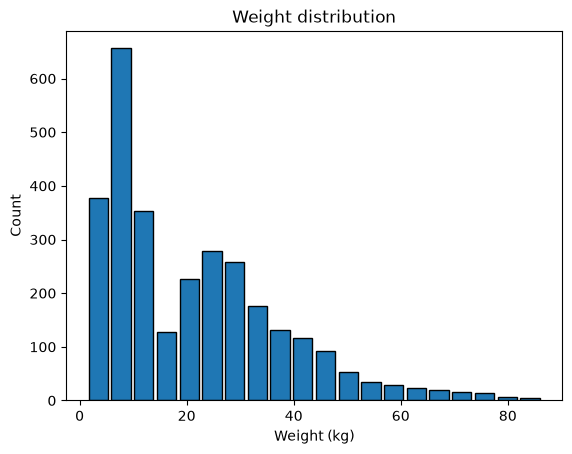

In [31]:
show_plt(df["Weight (kg)"], "Weight distribution", "Weight (kg)")

In [32]:
groups_breed = [group['Weight (kg)'].values for name, group in df.groupby('Breed')]
f_stat_breed, p_value_breed = stats.f_oneway(*groups_breed)

print("ANOVA: Breed -> Weight")
print(f"F-statistika: {f_stat_breed:.4f}")
print(f"p-vrijednost: {p_value_breed:.4f}")
print(f"Signifikantno (p<0.05): {p_value_breed < 0.05}")

male_weights = df[df['Gender'] == 'Male']['Weight (kg)']
female_weights = df[df['Gender'] == 'Female']['Weight (kg)']

t_stat_gender, p_value_gender = stats.ttest_ind(male_weights, female_weights)

print("\nt-test: Gender -> Weight")
print(f"t-statistika: {t_stat_gender:.4f}")
print(f"p-vrijednost: {p_value_gender:.4f}")
print(f"Signifikantno (p<0.05): {p_value_gender < 0.05}")

pearson_corr, p_value_pearson = stats.pearsonr(df['Age (Years)'], df['Weight (kg)'])

print("\nPearson korelacija: Age -> Weight")
print(f"Koeficijent: {pearson_corr:.4f}")
print(f"p-vrijednost: {p_value_pearson:.4f}")
print(f"Signifikantno (p<0.05): {p_value_pearson < 0.05}")

groups_color = [group['Weight (kg)'].values for name, group in df.groupby('Color')]
f_stat_color, p_value_color = stats.f_oneway(*groups_color)

print("\nANOVA: Color -> Weight (kontrolna provjera)")
print(f"F-statistika: {f_stat_color:.4f}")
print(f"p-vrijednost: {p_value_color:.4f}")
print(f"Signifikantno (p<0.05): {p_value_color < 0.05}")

ANOVA: Breed -> Weight
F-statistika: 1091.9925
p-vrijednost: 0.0000
Signifikantno (p<0.05): True

t-test: Gender -> Weight
t-statistika: 3.1364
p-vrijednost: 0.0017
Signifikantno (p<0.05): True

Pearson korelacija: Age -> Weight
Koeficijent: -0.0031
p-vrijednost: 0.8671
Signifikantno (p<0.05): False

ANOVA: Color -> Weight (kontrolna provjera)
F-statistika: 1.3993
p-vrijednost: 0.1380
Signifikantno (p<0.05): False


In [33]:
rottweiler_breed = df[df['Breed'] == 'Rottweiler']
pearson_isolated, p_isolated = stats.pearsonr(rottweiler_breed['Age (Years)'], rottweiler_breed['Weight (kg)'])
print(f"Rottweiler - Pearson: {pearson_isolated:.4f}, p={p_isolated:.4f}")

young_dogs = df[df['Age (Years)'] <= 2]
pearson_young, p_young = stats.pearsonr(young_dogs['Age (Years)'], young_dogs['Weight (kg)'])
print(f"Psi ≤2 godine - Pearson: {pearson_young:.4f}, p={p_young:.4f}")

Rottweiler - Pearson: 0.2232, p=0.0151
Psi ≤2 godine - Pearson: 0.1482, p=0.0021


Encoding variables

One-hot encoding

In [34]:
X_full = pd.get_dummies(
    df,
    columns=['Breed', 'Gender', 'Color'],
    drop_first=True
)

y = X_full['Weight (kg)']
X_full = X_full.drop('Weight (kg)', axis=1)

print(f"Full shape -> {X_full.shape}")
print(f"First 10 columns -> {X_full.columns.tolist()[:10]}")

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)
print(f"Train shape -> {X_train.shape}")
print(f"Test shape -> {X_test.shape}")

Full shape -> (3000, 69)
First 10 columns -> ['Age (Years)', 'Breed_Akita', 'Breed_Alaskan Malamute', 'Breed_Australian Shepherd', 'Breed_Basenji', 'Breed_Beagle', 'Breed_Belgian Malinois', 'Breed_Bernese Mountain Dog', 'Breed_Bichon Frise', 'Breed_Bloodhound']
Train shape -> (2400, 69)
Test shape -> (600, 69)


Model training and optimization

Linear Regression

In [35]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)

print("Linear Regression")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train_lr):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_lr)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train_lr):.4f}")
print()
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_lr):.3f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_lr)):.3f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_lr):.4f}")
print()
print(f"ΔR²:    {(abs(r2_score(y_train, y_pred_train_lr) - r2_score(y_test, y_pred_test_lr))):.4f}")

Linear Regression
Train MAE:  2.151
Train RMSE: 3.456
Train R²:   0.9558

Test MAE:   2.319
Test RMSE:  3.565
Test R²:    0.9460

ΔR²:    0.0098


Random Forest

In [36]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

print("Random Forest")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train_rf):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_rf)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train_rf):.4f}")
print()
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_rf):.3f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_rf)):.3f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_rf):.4f}")
print()
print(f"ΔR²:    {(abs(r2_score(y_train, y_pred_train_rf) - r2_score(y_test, y_pred_test_rf))):.4f}")

Random Forest
Train MAE:  0.866
Train RMSE: 1.511
Train R²:   0.9916

Test MAE:   2.262
Test RMSE:  3.746
Test R²:    0.9404

ΔR²:    0.0511


In [37]:
rf_model_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model_tuned.fit(X_train, y_train)

y_pred_train_tuned = rf_model_tuned.predict(X_train)
y_pred_test_tuned = rf_model_tuned.predict(X_test)

print("Random Forest (tuned)")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train_tuned):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_tuned)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train_tuned):.4f}")
print()
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_tuned):.3f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_tuned)):.3f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_tuned):.4f}")
print()
print(f"ΔR²:    {(abs(r2_score(y_train, y_pred_train_tuned) - r2_score(y_test, y_pred_test_tuned))):.4f}")

Random Forest (tuned)
Train MAE:  7.356
Train RMSE: 8.716
Train R²:   0.7190

Test MAE:   7.461
Test RMSE:  8.869
Test R²:    0.6660

ΔR²:    0.0530


In [38]:
rf_model_v2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model_v2.fit(X_train, y_train)

y_pred_train_v2 = rf_model_v2.predict(X_train)
y_pred_test_v2 = rf_model_v2.predict(X_test)

print("Random Forest (v2 - blaža regularizacija)")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train_v2):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_v2)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train_v2):.4f}")
print()
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_v2):.3f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_v2)):.3f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_v2):.4f}")
print()
print(f"ΔR²:    {(abs(r2_score(y_train, y_pred_train_v2) - r2_score(y_test, y_pred_test_v2))):.4f}")

Random Forest (v2 - blaža regularizacija)
Train MAE:  4.169
Train RMSE: 5.618
Train R²:   0.8833

Test MAE:   4.804
Test RMSE:  6.328
Test R²:    0.8299

ΔR²:    0.0533


In [39]:
param_grid = {
    'max_depth': [None, 15, 20, 30],
    'min_samples_leaf': [1, 2, 3, 5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Najbolji parametri:", grid_search.best_params_)
best_rf_params = {
    "n_jobs": -1,
    "n_estimators": 200,
    "random_state": 42,
    **grid_search.best_params_
}

best_rf = grid_search.best_estimator_
y_pred_train_best = best_rf.predict(X_train)
y_pred_test_best = best_rf.predict(X_test)

print("\nRandom Forest (GridSearch)")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train_best):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_best)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train_best):.4f}")
print()
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_best):.3f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_best)):.3f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_best):.4f}")
print()
print(f"ΔR²:    {(abs(r2_score(y_train, y_pred_train_best) - r2_score(y_test, y_pred_test_best))):.4f}")

Najbolji parametri: {'max_depth': None, 'min_samples_leaf': 5}

Random Forest (GridSearch)
Train MAE:  1.819
Train RMSE: 3.094
Train R²:   0.9646

Test MAE:   2.119
Test RMSE:  3.473
Test R²:    0.9488

ΔR²:    0.0158


Feature importance

Linear Regression

In [40]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled['Age (Years)'] = scaler.fit_transform(X_train[['Age (Years)']])
X_test_scaled['Age (Years)'] = scaler.transform(X_test[['Age (Years)']])

lr_model_scaled = LinearRegression()
lr_model_scaled.fit(X_train_scaled, y_train)

lr_coefficients = pd.Series(lr_model_scaled.coef_, index=X_train_scaled.columns)
lr_coefficients_sorted = lr_coefficients.sort_values(key=abs, ascending=False)
print(lr_coefficients_sorted.head(10))

Breed_Great Dane              39.978779
Breed_Saint Bernard           39.793816
Breed_Pomeranian             -24.968678
Breed_Chihuahua              -24.344893
Breed_Yorkshire Terrier      -24.011510
Breed_Maltese                -23.826626
Breed_Papillon               -23.429491
Breed_Havanese               -22.301620
Breed_Jack Russell Terrier   -21.510279
Breed_Rottweiler              21.502257
dtype: float64


In [41]:
full_rank = lr_coefficients_sorted.reset_index()
full_rank.columns = ['variable', 'coefficient']
print(full_rank[full_rank['variable'].isin(['Age (Years)', 'Gender_Male'])])
print(f"Age je na poziciji: {full_rank[full_rank['variable']=='Age (Years)'].index[0]+1} od {len(full_rank)}")
print(f"Gender je na poziciji: {full_rank[full_rank['variable']=='Gender_Male'].index[0]+1} od {len(full_rank)}")

       variable  coefficient
50  Gender_Male     1.719909
62  Age (Years)     0.196019
Age je na poziciji: 63 od 69
Gender je na poziciji: 51 od 69


Random Forest

In [42]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=False)

print(importances_sorted.head(10))

Breed_Saint Bernard           0.162109
Breed_Great Dane              0.157090
Breed_Rottweiler              0.142284
Breed_Bloodhound              0.052651
Breed_Akita                   0.044134
Breed_Dogo Argentino          0.042285
Breed_Bernese Mountain Dog    0.040246
Breed_Doberman Pinscher       0.034535
Breed_Alaskan Malamute        0.032656
Breed_Weimaraner              0.028401
dtype: float64


In [43]:
breed_total_importance = importances[importances.index.str.startswith('Breed_')].sum()
gender_total_importance = importances[importances.index.str.startswith('Gender_')].sum()
color_total_importance = importances[importances.index.str.startswith('Color_')].sum()
age_importance = importances['Age (Years)']

print(f"Breed (ukupno): {breed_total_importance:.4f}")
print(f"Age: {age_importance:.4f}")
print(f"Gender (ukupno): {gender_total_importance:.4f}")
print(f"Color (ukupno): {color_total_importance:.4f}")

Breed (ukupno): 0.9850
Age: 0.0091
Gender (ukupno): 0.0053
Color (ukupno): 0.0006


Remove Color (Iteration B)

In [44]:
color_cols = [col for col in X_train.columns if col.startswith('Color_')]

X_train_B = X_train.drop(columns=color_cols)
X_test_B = X_test.drop(columns=color_cols)

print(X_train_B.shape, X_test_B.shape)

lr_model_B = LinearRegression()
lr_model_B.fit(X_train_B, y_train)

y_pred_train_lr_B = lr_model_B.predict(X_train_B)
y_pred_test_lr_B = lr_model_B.predict(X_test_B)

print("Linear Regression - Iteracija B (bez Color)")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train_lr_B):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_lr_B)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train_lr_B):.4f}")
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_lr_B):.3f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_lr_B)):.3f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_lr_B):.4f}")

rf_model_B = RandomForestRegressor(
    **best_rf_params
)
rf_model_B.fit(X_train_B, y_train)

y_pred_train_rf_B = rf_model_B.predict(X_train_B)
y_pred_test_rf_B = rf_model_B.predict(X_test_B)

print("\nRandom Forest - Iteracija B (bez Color)")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train_rf_B):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_rf_B)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train_rf_B):.4f}")
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_rf_B):.3f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_rf_B)):.3f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_rf_B):.4f}")

(2400, 54) (600, 54)
Linear Regression - Iteracija B (bez Color)
Train MAE:  2.151
Train RMSE: 3.469
Train R²:   0.9555
Test MAE:   2.298
Test RMSE:  3.577
Test R²:    0.9457

Random Forest - Iteracija B (bez Color)
Train MAE:  1.823
Train RMSE: 3.104
Train R²:   0.9644
Test MAE:   2.120
Test RMSE:  3.473
Test R²:    0.9488


In [45]:
gender_cols = [col for col in X_train_B.columns if col.startswith('Gender_')]

X_train_C = X_train_B.drop(columns=gender_cols)
X_test_C = X_test_B.drop(columns=gender_cols)

print(X_train_C.shape, X_test_C.shape)

lr_model_C = LinearRegression()
lr_model_C.fit(X_train_C, y_train)
y_pred_train_lr_C = lr_model_C.predict(X_train_C)
y_pred_test_lr_C = lr_model_C.predict(X_test_C)

print("Linear Regression - Iteracija C (bez Color, bez Gender)")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train_lr_C):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_lr_C)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train_lr_C):.4f}")
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_lr_C):.3f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_lr_C)):.3f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_lr_C):.4f}")

rf_model_C = RandomForestRegressor(
    **best_rf_params
)
rf_model_C.fit(X_train_C, y_train)
y_pred_train_rf_C = rf_model_C.predict(X_train_C)
y_pred_test_rf_C = rf_model_C.predict(X_test_C)

print("\nRandom Forest - Iteracija C (bez Color, bez Gender)")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train_rf_C):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_rf_C)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train_rf_C):.4f}")
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_rf_C):.3f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_rf_C)):.3f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_rf_C):.4f}")

(2400, 53) (600, 53)
Linear Regression - Iteracija C (bez Color, bez Gender)
Train MAE:  2.192
Train RMSE: 3.577
Train R²:   0.9527
Test MAE:   2.375
Test RMSE:  3.715
Test R²:    0.9414

Random Forest - Iteracija C (bez Color, bez Gender)
Train MAE:  1.993
Train RMSE: 3.261
Train R²:   0.9607
Test MAE:   2.374
Test RMSE:  3.732
Test R²:    0.9409


In [46]:
X_train_D = X_train_C.drop(columns=['Age (Years)'])
X_test_D = X_test_C.drop(columns=['Age (Years)'])

print(X_train_D.shape, X_test_D.shape)

lr_model_D = LinearRegression()
lr_model_D.fit(X_train_D, y_train)
y_pred_train_lr_D = lr_model_D.predict(X_train_D)
y_pred_test_lr_D = lr_model_D.predict(X_test_D)

print("Linear Regression - Iteracija D (samo Breed)")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train_lr_D):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_lr_D)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train_lr_D):.4f}")
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_lr_D):.3f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_lr_D)):.3f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_lr_D):.4f}")

rf_model_D = RandomForestRegressor(
    **best_rf_params
)
rf_model_D.fit(X_train_D, y_train)
y_pred_train_rf_D = rf_model_D.predict(X_train_D)
y_pred_test_rf_D = rf_model_D.predict(X_test_D)

print("\nRandom Forest - Iteracija D (samo Breed)")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train_rf_D):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_rf_D)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train_rf_D):.4f}")
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_rf_D):.3f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_rf_D)):.3f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_rf_D):.4f}")

(2400, 52) (600, 52)
Linear Regression - Iteracija D (samo Breed)
Train MAE:  2.185
Train RMSE: 3.581
Train R²:   0.9526
Test MAE:   2.371
Test RMSE:  3.729
Test R²:    0.9410

Random Forest - Iteracija D (samo Breed)
Train MAE:  2.185
Train RMSE: 3.581
Train R²:   0.9526
Test MAE:   2.371
Test RMSE:  3.730
Test R²:    0.9409
